# The POLONAISE UHDM data release

**Paper element.** Supplemental Material, Analysis Code and Data Release: this is
a guided tour of the file that section describes.

**Private.** A guided tour of the POLONAISE UHDM data release: **two**
self-describing HDF5 files holding the **whole limit-setting calculation** —
not just the final contour — as a dense array over
(`f_DM`, atmosphere, sensor mode, `alpha_n`, `m_DM`, mediator range `lambda`).
The two leading axes are length 1 in each file, because the release ships one
hypothesis per file: **A** is $f_\mathrm{DM}$ = 1 with atmospheric attenuation,
the plane the Letter quotes its couplings on, and **B** is $f_\mathrm{DM}$ = 0.1
with attenuation off, the plane the composite benchmark is quoted on. Everything
else — axes, detector inputs, reference curves — is identical between them.
Notebooks 01–05 read these files through `luhdm.release` rather than
recomputing any physics, so a notebook run and a cluster run cannot drift.

**What's inside**, group by group (the full schema table lives in
[`release/README.md`](../release/README.md), which this notebook mirrors and
does not contradict):

- `/axes` — every coordinate array, including the two **hypothesis** axes
  `f_dm` and `atmosphere`, one value each (section 3 below).
- `/results` — the cube itself: `extremeness` (the optimum-interval
  confidence), `mu` (expected counts), `status` (how the cell was obtained),
  and the mode-less `n_transit`.
- `/detector` — the observed candidate lists, the pre-selection blips, and
  the measured detection efficiency $\varepsilon(q)$ per mode.
- `/halo` — an independent, coarser flux/reach diagnostic grid, for
  intuition and figures.
- `/reference_curves` — showcase arrival-speed and raw-spectrum curves (the
  data behind notebook 02).

**Two ways in**, covered in that order below: **(1)** raw `h5py` plus the
standalone, dependency-light
[`release/luhdm_release.py`](../release/luhdm_release.py) reader — no
`luhdm` install required — and **(2)** the `luhdm.release` convenience loader,
for anyone who already has this repository checked out.

**One thing the files do not do for you.** The impact-parameter integral is
uncapped in this release, so the stored surfaces keep reporting exclusion at
masses where the halo delivers essentially no flybys through the apparatus. The
region is closed on the right by a **flux cut** `m_cut`, stored as a root
attribute together with the $N_\text{req} = 3$ transits-within-10-cm standard
it assumes — an assumption, not a measurement — and it is *not* baked into
`extremeness`. Section 4 below applies it.

Everything here is schema-driven: it reads tag names, axis lengths, the massless
sentinel and the cut from the files' own attributes, never from a hardcoded
list, so it keeps working unchanged when a newer cube supersedes this one.

**A path note.** The raw-`h5py` walkthrough of section 1 deliberately does not
import `luhdm`, so it needs a filename; the cell below names both released
files once, so nothing later in the notebook can read a different one.

## 1. You do not need to install anything

The release is plain HDF5 with dimension scales and per-dataset `units` /
`description` attributes. `h5py`, `h5ls`, `h5dump`, MATLAB, Julia, IDL and
xarray (via h5netcdf) all open it — nothing to `pip install` beyond whatever
HDF5 binding you already have.

In [1]:
%matplotlib inline
import json
import sys
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

from luhdm import release as _release

REPO = Path.cwd().parent            # notebooks/ -> repo root
RELEASE_DIR = REPO / "release"
# The two cubes this repository ships publicly. Their lambda axes carry the
# three physics mediator slices (2 mm, 200 µm, 20 µm), a 200 m convergence
# check, and the massless sentinel. The internal full-lambda cube stays on
# luhdm.release.DEFAULT_PATH for the paper-figure scripts. Section 1 below
# opens file A with bare h5py to show that no luhdm code is needed to read it.
H5_A = RELEASE_DIR / "luhdm_datarelease_v8_A_f1_atm.h5"       # f_DM = 1,   atm on
H5_B = RELEASE_DIR / "luhdm_datarelease_v8_B_f0p1_noatm.h5"   # f_DM = 0.1, atm off
H5_PATH = H5_A          # the file the single-file walkthroughs below open
for p in (H5_A, H5_B):
    assert p.exists(), f"no cube at {p} -- point this at whatever release/ holds"
    print(f"cube: {p.name}  ({p.stat().st_size / 1e6:.2f} MB)")

cube: luhdm_datarelease_v8_A_f1_atm.h5  (0.55 MB)
cube: luhdm_datarelease_v8_B_f0p1_noatm.h5  (0.59 MB)


In [2]:
# The whole tree, straight from h5py -- no luhdm code, just the HDF5 library.
def show(name, obj):
    if isinstance(obj, h5py.Dataset):
        units = obj.attrs.get("units", "")
        print(f"{name:32s} {str(obj.shape):20s} {str(obj.dtype):8s} [{units}]")

with h5py.File(H5_PATH, "r") as f:
    print(f.attrs["version_tag"], f["results/extremeness"].shape)
    f.visititems(show)

v8.0-night-m0p356mg-q1TeV-nocap-wmarg (1, 1, 3, 44, 119, 5)
axes/alpha_halo_n                (64,)                float64  [1]
axes/alpha_n                     (44,)                float64  [1]
axes/atmosphere                  (1,)                 int8     [bool]
axes/f_dm                        (1,)                 float64  [1]
axes/lambda_m                    (5,)                 float64  [m]
axes/m_phi_gev                   (5,)                 float64  [GeV]
axes/mass_gev                    (119,)               float64  [GeV]
axes/mass_halo_gev               (64,)                float64  [GeV]
axes/mode                        (3,)                 uint8    [1]
detector/all_blips_mode1         (66,)                float64  [eV]
detector/all_blips_mode2         (99,)                float64  [eV]
detector/all_blips_mode3         (443,)               float64  [eV]
detector/eff_1_df2               (400,)               float64  [1]
detector/eff_1_df3               (400,)               flo

`/results/extremeness` is shaped `(f_dm, atmosphere, mode, alpha_n, mass_gev,
lambda_m)`, with the two leading axes length 1 in this release. A first slice,
hard-coding the leading indices to see the shape of things — **do not do this in
real code** even when the axes are length 1, resolve indices from the axes
instead (as every section below does):

In [3]:
with h5py.File(H5_PATH, "r") as f:
    p = f["results/extremeness"][0, 0, 0, :, :, -1]   # f_DM idx0, atm idx0, mode idx0, massless
    print("axis lengths:", {d: len(f["axes"][d]) for d in f["axes"]})
    print("excluded cells at 95% CL:", int((p >= 0.95).sum()), "of", p.size)

    # named mediator-range tags and the massless convention -- read from the
    # file's own attributes, never assumed
    tags = json.loads(f["axes/lambda_m"].attrs["tags_json"])
    n_finite = int(f["axes/lambda_m"].attrs["n_finite"])
# tags_json is inherited from the parent scan and names ranges this file does
# not carry: a tag is not a promise that the slice is here. Check against the
# axis before using one.
with h5py.File(H5_PATH, "r") as f:
    lam_axis = f["axes/lambda_m"][:]
on_axis = {k: v for k, v in tags.items() if np.isin(v, lam_axis)}
print("named lambda tags (m):", tags)
print("        of those, on this file's axis:", on_axis)
print(f"lambda_m axis: {n_finite} finite values (ascending) + 1 massless "
      f"sentinel (inf, where m_phi_gev == 0.0)")
print(f"the untagged finite entry is the convergence-check slice at "
      f"{lam_axis[n_finite - 1]:g} m -- not a physics point")

axis lengths: {'alpha_halo_n': 64, 'alpha_n': 44, 'atmosphere': 1, 'f_dm': 1, 'lambda_m': 5, 'm_phi_gev': 5, 'mass_gev': 119, 'mass_halo_gev': 64, 'mode': 3}
excluded cells at 95% CL: 2516 of 5236
named lambda tags (m): {'2m': 2.0, '20cm': 0.2, '2cm': 0.02, '2mm': 0.002, '200um': 0.0002, '20um': 2e-05, '10um': 1e-05, '2um': 2e-06}
        of those, on this file's axis: {'2mm': 0.002, '200um': 0.0002, '20um': 2e-05}
lambda_m axis: 4 finite values (ascending) + 1 massless sentinel (inf, where m_phi_gev == 0.0)
the untagged finite entry is the convergence-check slice at 200 m -- not a physics point


### The standalone reader (no `luhdm` install needed)

[`release/luhdm_release.py`](../release/luhdm_release.py) is a **single
self-contained file** — copy it next to the `.h5` and `import` it. It needs
only `numpy` and `h5py` (`pandas` is imported lazily inside `to_dataframe()`
and is optional), never imports the `luhdm` analysis package, and is entirely
**schema-driven**: axis names, tags and the massless sentinel come from the
file, so it keeps working across cube versions. What it adds over raw
`h5py`: selection by physical value (`mode=2`, `lam='200um'`, `f_dm=1.0`,
`atmosphere=True`, ...) with helpful errors, slices that carry their axes
with them, the exclusion-band convention (section 4), and a one-call
`summary()`. Note the explicit `f_dm=`: the reader's fallback is
`attrs['f_dm_default']` = 0.1, the build-side baseline, which is not on file
A's axis at all.

In [4]:
sys.path.insert(0, str(RELEASE_DIR))
import luhdm_release

srel = luhdm_release.open_release(H5_PATH)
print(srel)
srel.summary()

<Release '/home/tunnell/code/luhdm/release/luhdm_datarelease_v8_A_f1_atm.h5' (v8.0-night-m0p356mg-q1TeV-nocap-wmarg)>
POLONAISE UHDM data release   v8.0-night-m0p356mg-q1TeV-nocap-wmarg
file            : /home/tunnell/code/luhdm/release/luhdm_datarelease_v8_A_f1_atm.h5
format          : luhdm-datarelease version 2 (schema 1)
created         : 2026-08-12T16:20:24.121864+00:00
exposure        : 790,778 s  (219.66 h)
impact-param cap: none (uncapped)
recommended CL  : 0.95

hypothesis axes
  f_dm          : [1.0]  (default 0.1) -- DM fraction, pure flux scale
  atmosphere    : [1] -> [True]  (1/True = attenuation applied)
  mode          : [1, 2, 3]

axes
  alpha_halo_n    n=64    2e-11 .. 1                   [1]
                  coupling alpha_n (halo/flux-map 64 grid)
  alpha_n         n=44    1e-10 .. 1                   [1]
                  per-neutron coupling alpha_n
  atmosphere      n=1     [1]                          [bool]
                  1 = attenuation through the atmosph

The quickstart from the reader's own docstring: a slice, an excluded band, and
a single-cell dump, entirely without installing `luhdm`.

In [5]:
sl = srel.get("extremeness", mode=1, lam="200um", f_dm=1.0, atmosphere=True)
print(sl)                                        # axes travel with the array
print("excluded cells:", int((sl.values >= 0.95).sum()))

band = srel.excluded_band(mode=1, lam="200um", f_dm=1.0)   # 95% CL, per mass
print(band)

cell = srel.cell(mode=2, alpha=1e-3, mass=1e8, lam="200um", f_dm=1.0)
print({k: cell[k] for k in
       ("mass_gev", "alpha_n", "mu", "extremeness", "status", "status_meaning")})

<Slice extremeness [1] (alpha_n=44, mass_gev=119) at f_dm=1, atmosphere=True, mode=1, lambda_m=0.0002>
excluded cells: 828
<ExcludedBand 95% CL at f_dm=1, atmosphere=True, mode=1, lambda_m=0.0002: 42/119 masses excluded, mass range 6.849e+05..5.371e+10 GeV>
{'mass_gev': 96471330.72266711, 'alpha_n': 0.0009478599776522384, 'mu': 1332.8138427734375, 'extremeness': 1.0, 'status': 3, 'status_meaning': 'mu>mu_cap: expected counts above the MC cap; extremeness is exactly 1 (excluded)'}


## 2. For people with this repository: `luhdm.release`

If you already have this repo checked out, `luhdm.release` is a thinner,
faster-to-type convenience layer over the same file: eager axis loading,
exact/nearest index resolution, hyperslab plane reads (`mass_plane`,
`lambda_plane`, `composite`), and the shared best-mass criterion that keeps
notebooks 01 and 04 from drifting apart. `open_release()` with no argument
opens `luhdm.release.DEFAULT_PATH` (the repository's internal analysis cube);
here both released paths are passed explicitly, so this section reads the same
file section 1 opened by name, plus its companion.

In [6]:
from luhdm import release

rel = release.open_release(H5_A)    # the same file section 1 opened by name
relB = release.open_release(H5_B)   # its companion hypothesis
print(rel)
print(relB)
print(rel.tree())

<Release /home/tunnell/code/luhdm/release/luhdm_datarelease_v8_A_f1_atm.h5 (v8.0-night-m0p356mg-q1TeV-nocap-wmarg)>
<Release /home/tunnell/code/luhdm/release/luhdm_datarelease_v8_B_f0p1_noatm.h5 (v8.0-night-m0p356mg-q1TeV-nocap-wmarg)>
/
  axes/
    alpha_halo_n  (64,) float64  [1]
    alpha_n  (44,) float64  [1]
    atmosphere  (1,) int8  [bool]
    f_dm  (1,) float64  [1]
    lambda_m  (5,) float64  [m]
    m_phi_gev  (5,) float64  [GeV]
    mass_gev  (119,) float64  [GeV]
    mass_halo_gev  (64,) float64  [GeV]
    mode  (3,) uint8  [1]
  detector/
    all_blips_mode1  (66,) float64  [eV]
    all_blips_mode2  (99,) float64  [eV]
    all_blips_mode3  (443,) float64  [eV]
    eff_1_df2  (400,) float64  [1]
    eff_1_df3  (400,) float64  [1]
    eff_2_df2  (400,) float64  [1]
    eff_2_df3  (400,) float64  [1]
    eff_3_df2  (400,) float64  [1]
    eff_3_df3  (400,) float64  [1]
    events_mode1  (8,) float64  [GeV]
    events_mode2  (26,) float64  [GeV]
    events_mode3  (126,) float6

In [7]:
# same one-cell dump as the standalone reader, through the loader
info = rel.cell(mass=1e8, alpha=1e-3, lam="200um", mode=2, f_dm=1.0)
print("resolved cell (nearest-in-log10 for mass/alpha, exact for lambda):")
for k, v in info.items():
    print(f"  {k:16s} {v}")

resolved cell (nearest-in-log10 for mass/alpha, exact for lambda):
  mass_gev         96471330.72266711
  alpha_n          0.0009478599776522384
  lambda_m         0.0002
  f_dm             1.0
  atmosphere       True
  indices          (30, 25, 1)
  extremeness      1.0
  mu               1332.8138427734375
  n_transit        4962.81005859375
  status           3
  bmax             0.002289521973580122
  n_transit_halo   11887.509765625


## 3. Two files, one hypothesis each

The two leading axes of every `/results` dataset are **hypotheses**, not
measurements. Earlier versions of this release computed all four combinations
and shipped them in one cube; this one ships the two the paper actually uses,
one per file:

| file | `f_dm` | `atmosphere` | what it is for |
|---|---|---|---|
| `luhdm_datarelease_v8_A_f1_atm.h5` | 1.0 | 1 (attenuated) | this species is all of the dark matter, propagated through the overburden — the plane the Letter's $\alpha_n$ limits are quoted on |
| `luhdm_datarelease_v8_B_f0p1_noatm.h5` | 0.1 | 0 (bare halo) | a tenth of the dark matter, no overburden — the plane the composite cross-section benchmark is quoted on |

* **`f_dm`** is the fraction of the local dark-matter density carried by this
  species. It enters only as a flux normalisation, so `mu` and `n_transit`
  scale exactly linearly with it — `extremeness` does **not**, since it is a
  non-linear function of `mu`. That is why there are two files and not one
  rescaling: you cannot turn A into B with a multiplication.
* **`atmosphere`** selects whether the arrival flux has been propagated
  through the atmosphere/overburden. With it on, strongly coupled candidates
  can be slowed or stopped before reaching the sensor and the exclusion can
  close from above; with it off there is no such mechanism at all (see the
  caveat in section 4).

`attrs['f_dm_default']` is 0.1 in **both** files. It records the build-side
baseline the flux was normalised from, not the plane the file carries, and in
file A it is not even a value on the axis — anything that falls back to it will
ask file A for a hypothesis it does not have. The axis is the authority. Select
by value, never by position:

In [8]:
for path in (H5_A, H5_B):
    with h5py.File(path, "r") as f:
        f_dm_axis = f["axes/f_dm"][:]
        atm_axis = f["axes/atmosphere"][:]
        mode_axis = f["axes/mode"][:]
        f_dm_default = float(f.attrs["f_dm_default"])
    on_axis = bool(np.isin(f_dm_default, f_dm_axis))
    print(f"{path.name}")
    print(f"  axes/f_dm       = {f_dm_axis}   axes/atmosphere = {atm_axis}"
          f"   axes/mode = {mode_axis}")
    print(f"  attrs['f_dm_default'] = {f_dm_default} -> on this file's axis? "
          f"{on_axis}")

# resolve by value, exactly as you would with longer axes
with h5py.File(H5_A, "r") as f:
    i_f = int(np.flatnonzero(f["axes/f_dm"][:] == 1.0)[0])
    i_atm_on = int(np.flatnonzero(f["axes/atmosphere"][:] == 1)[0])
    i_mod = int(np.flatnonzero(f["axes/mode"][:] == 2)[0])
print(f"\nfile A indices: f_dm=1.0 -> {i_f}, atmosphere ON -> {i_atm_on}, "
      f"mode 2 -> {i_mod}")

luhdm_datarelease_v8_A_f1_atm.h5
  axes/f_dm       = [1.]   axes/atmosphere = [1]   axes/mode = [1 2 3]
  attrs['f_dm_default'] = 0.1 -> on this file's axis? False
luhdm_datarelease_v8_B_f0p1_noatm.h5
  axes/f_dm       = [0.1]   axes/atmosphere = [0]   axes/mode = [1 2 3]
  attrs['f_dm_default'] = 0.1 -> on this file's axis? True

file A indices: f_dm=1.0 -> 0, atmosphere ON -> 0, mode 2 -> 1


The loader does exactly this resolution for you via the `f_dm=` /
`atmosphere=` keywords on every accessor. Both hypotheses, one mode and
mediator range at a time — the same plane, read out of the two files:

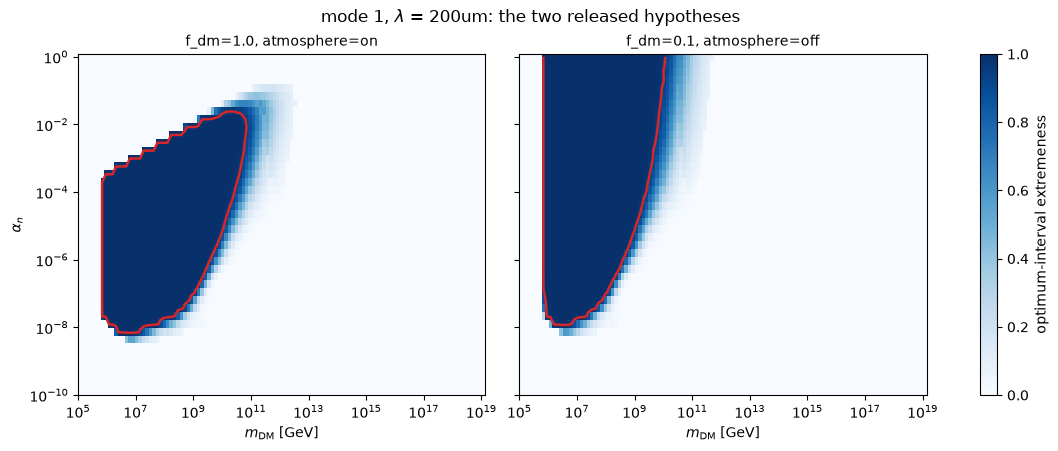

In [9]:
FIG_MODE, FIG_LAM = 1, "200um"
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4), sharex=True, sharey=True,
                         constrained_layout=True)
mesh = None
for a, (r, f_dm, atm) in zip(axes, [(rel, 1.0, True), (relB, 0.1, False)]):
    P = r.mass_plane("extremeness", mode=FIG_MODE, lam=FIG_LAM,
                     f_dm=f_dm, atmosphere=atm)
    mesh = a.pcolormesh(r.axes.mass_gev, r.axes.alpha_n, P, cmap="Blues",
                        vmin=0, vmax=1, shading="auto")
    a.contour(r.axes.mass_gev, r.axes.alpha_n, P, levels=[0.95],
              colors="#d62728", linewidths=1.8)
    a.set_xscale("log")
    a.set_yscale("log")
    a.set_xlabel(r"$m_{\rm DM}$ [GeV]")
    a.set_title(f"f_dm={f_dm}, atmosphere={'on' if atm else 'off'}", fontsize=10)
axes[0].set_ylabel(r"$\alpha_n$")
fig.colorbar(mesh, ax=axes, label="optimum-interval extremeness")
fig.suptitle(f"mode {FIG_MODE}, $\\lambda$ = {FIG_LAM}: "
             "the two released hypotheses", fontsize=12)
plt.show()

## 4. The exclusion-band convention

`extremeness` is the probability that a background-free pseudo-experiment
under a hypothesis looks *less* extreme than the observed data (Yellin's
optimum-interval method). A grid point is **excluded at confidence `C`**
when `extremeness >= C` — a 2-D exclusion region is just that level set,
contoured directly.

For a boundary *in the coupling*, the project quotes the interpolated
crossing rather than the last excluded grid point: at each mass, the run of
`alpha_n` indices with `extremeness >= C` is bracketed and the level crossing
is found by linear interpolation in `log10(alpha_n)`. If the excluded run
already starts at the first (or ends at the last) scanned coupling there is
nothing to bracket, and that edge **saturates** at the end of the grid — a
property of the scan range, not a measurement.

Three independent routes to the same number: the loader, the standalone
reader, and the raw arithmetic each of them wraps. None of the three applies
the mass cut — that comes next.

In [10]:
MASS, LAM, MODE = 1e8, "200um", 1

# 1) luhdm.release
lo, hi = rel.excluded_alpha_band(mass=MASS, lam=LAM, mode=MODE, f_dm=1.0)
print(f"loader             95% CL: alpha_n in [{lo:.4e}, {hi:.4e}]")

# 2) the standalone reader -- no luhdm import at all
band = srel.excluded_band(mode=MODE, lam=LAM, f_dm=1.0)
im = int(np.argmin(np.abs(np.log10(band.mass_gev) - np.log10(MASS))))
print(f"standalone reader  95% CL: alpha_n in "
      f"[{band.alpha_lo[im]:.4e}, {band.alpha_hi[im]:.4e}]  "
      f"(nearest grid mass {band.mass_gev[im]:.4g} GeV)")

# 3) by hand, straight off the HDF5 column -- what both of the above wrap
with h5py.File(H5_PATH, "r") as f:
    alpha = f["axes/alpha_n"][:]
    mass_ax = f["axes/mass_gev"][:]
    lam_ax = f["axes/lambda_m"][:]
    ifd = int(np.flatnonzero(f["axes/f_dm"][:] == 1.0)[0])
    iat = int(np.flatnonzero(f["axes/atmosphere"][:] == 1)[0])
    imode = int(np.flatnonzero(f["axes/mode"][:] == MODE)[0])
    im2 = int(np.argmin(np.abs(np.log10(mass_ax) - np.log10(MASS))))
    il = int(np.flatnonzero(lam_ax == 2e-4)[0])
    column = f["results/extremeness"][ifd, iat, imode, :, im2, il]

def band_by_hand(alpha, p, level):
    idx = np.where(p >= level)[0]
    if idx.size == 0:
        return np.nan, np.nan
    lo = (np.log10(alpha[0]) if idx[0] == 0 else np.interp(
        level, p[idx[0] - 1:idx[0] + 1], np.log10(alpha[idx[0] - 1:idx[0] + 1])))
    hi = (np.log10(alpha[-1]) if idx[-1] == len(p) - 1 else np.interp(
        -level, -p[idx[-1]:idx[-1] + 2], np.log10(alpha[idx[-1]:idx[-1] + 2])))
    return 10 ** lo, 10 ** hi

lo_h, hi_h = band_by_hand(alpha, column, 0.95)
print(f"by hand (numpy)    95% CL: alpha_n in [{lo_h:.4e}, {hi_h:.4e}]  "
      f"(mass snapped to {mass_ax[im2]:.4g} GeV)")

loader             95% CL: alpha_n in [1.8653e-08, 2.8411e-03]
standalone reader  95% CL: alpha_n in [1.8653e-08, 2.8411e-03]  (nearest grid mass 9.647e+07 GeV)
by hand (numpy)    95% CL: alpha_n in [1.8653e-08, 2.8411e-03]  (mass snapped to 9.647e+07 GeV)


### The mass cut: the edge that is not in the surfaces

`extremeness` is a statement about statistics. It says nothing about whether a
flyby happened. With the impact-parameter integral uncapped, the two part
company at heavy mass: the number density falls as $1/m_\text{DM}$, and beyond
some mass the "signal" being excluded is a transit that never occurs anywhere
near the apparatus.

The release closes the region there with an explicit cut. Require the halo to
deliver at least $N_\text{req}$ particles through a $b_\text{cap}$ = 10 cm
aperture — the scale of the cryogenic hardware around the trap — during the
exposure:

$$N(m) = f_\mathrm{DM}\,\frac{\rho_0}{m}\,\langle v\rangle\,T_\text{obs}\,
\pi b_\text{cap}^2 \;\ge\; N_\text{req}
\qquad\Longrightarrow\qquad
m \le m_\text{cut} = \frac{f_\mathrm{DM}\,\rho_0\,\langle v\rangle\,
T_\text{obs}\,\pi b_\text{cap}^2}{N_\text{req}}$$

**$N_\text{req} = 3$ is an assumption of this release, not a measurement.** It
is the Poisson-zero standard, the same one the limit itself rests on, and
$m_\text{cut}$ is exactly inversely proportional to it — the cell below prints
the alternatives. Everything needed to recompute or move it is in the
attributes, and `m_cut_applied_to_stored_surfaces` is `False`, so the surfaces
stay uncapped and the choice stays yours.

In [11]:
for r in (rel, relB):
    a = r.attrs
    key = next(k for k in a if k.startswith("m_cut_") and k.endswith("_gev"))
    m_cut = float(a[key]); n_req = float(a["m_cut_n_transits_required"])
    b_cap = float(a["m_cut_b_cap_m"]); f_dm = float(r.f_dm_values[0])

    # recomputed from first principles, not read back
    rho_0, v_mean = 3.0e5, 245972.0            # GeV/m^3, m/s
    check = f_dm * rho_0 * v_mean * float(a["t_exposure_s"]) * np.pi * b_cap**2 / n_req
    print(f"f_dm = {f_dm:<4g} {key:<24s} = {m_cut:.4g} GeV   "
          f"(recomputed {check:.4g})")
    print(f"           N_req = {n_req:g} within {b_cap:g} m; applied to the "
          f"stored surfaces: {bool(a['m_cut_applied_to_stored_surfaces'])}")
    print("           " + "  ".join(
        f"N_req={n:g} -> {m_cut * n_req / n:.3g} GeV" for n in (1, 3, 6.8)))

# what it costs the massless mode-1 band in file A: apply it as a mask.
# The attribute is named for the hypothesis the file carries, so find it the
# same way the loop above does rather than typing the name out.
band_ml = srel.excluded_band(mode=1, lam="massless", f_dm=1.0)
m_cut_A = float(rel.attrs[next(k for k in rel.attrs
                               if k.startswith("m_cut_") and k.endswith("_gev"))])
ok = np.isfinite(band_ml.alpha_lo)
inside = ok & (band_ml.mass_gev <= m_cut_A)
print(f"\nmassless, mode 1, f_dm = 1: surfaces exclude {int(ok.sum())} masses "
      f"up to {band_ml.mass_gev[ok].max():.3g} GeV;")
print(f"  inside the cut, {int(inside.sum())} masses up to "
      f"{band_ml.mass_gev[inside].max():.3g} GeV. The other "
      f"{int((ok & ~inside).sum())} are a flux the halo does not deliver.")

f_dm = 1    m_cut_10cm_f1_gev        = 6.111e+14 GeV   (recomputed 6.111e+14)
           N_req = 3 within 0.1 m; applied to the stored surfaces: False
           N_req=1 -> 1.83e+15 GeV  N_req=3 -> 6.11e+14 GeV  N_req=6.8 -> 2.7e+14 GeV
f_dm = 0.1  m_cut_10cm_f0.1_gev      = 6.111e+13 GeV   (recomputed 6.111e+13)
           N_req = 3 within 0.1 m; applied to the stored surfaces: False
           N_req=1 -> 1.83e+14 GeV  N_req=3 -> 6.11e+13 GeV  N_req=6.8 -> 2.7e+13 GeV

massless, mode 1, f_dm = 1: surfaces exclude 112 masses up to 1.22e+19 GeV;
  inside the cut, 75 masses up to 4.67e+14 GeV. The other 37 are a flux the halo does not deliver.


**Caveat: upper edges that saturate are grid artefacts, not ceilings.** With
attenuation on, strong couplings can be stopped by the overburden and the
exclusion closes from above. With it off there is no such mechanism, so the
band continues past the top of the scanned `alpha_n` grid and the upper edge is
wherever the scan stopped. With the impact-parameter cap removed, that now also
happens in *part* of the attenuated file: an atmospheric ceiling exists at low
mass and runs out of coupling grid further up. Computed live against both
released files (so the fractions below move with the cubes, not with this
text):

In [12]:
for path in (H5_A, H5_B):
    with h5py.File(path, "r") as f:
        ext = f["results/extremeness"][0, 0]   # (mode, alpha, mass, lam)
        atm = int(f["axes/atmosphere"][0])
        f_dm = float(f["axes/f_dm"][0])

    above = ext >= 0.95
    any_exc = above.any(axis=1)                # any alpha excluded at (mode, mass, lam)
    top_exc = above[:, -1]                     # alpha_n = 1 (top of grid) excluded
    n = int(any_exc.sum())
    frac = 100 * (any_exc & top_exc).sum() / n if n else float("nan")
    print(f"f_dm={f_dm:g}, atmosphere={atm} ({'on' if atm else 'off'}): {n} "
          f"excluded (mode, mass, lambda) columns, {frac:.1f}% saturate at "
          f"alpha_n = 1")

f_dm=1, atmosphere=1 (on): 1046 excluded (mode, mass, lambda) columns, 30.1% saturate at alpha_n = 1
f_dm=0.1, atmosphere=0 (off): 973 excluded (mode, mass, lambda) columns, 100.0% saturate at alpha_n = 1


## 5. Status codes and the NaN policy

`/results/status` records how each cell was obtained:

| code | meaning | `extremeness` |
|---|---|---|
| `0` | the optimum-interval Monte Carlo ran | MC value in (0, 1) |
| `1` | **the cell raised an exception** | `NaN` (and `mu`, `n_transit` too) |
| `2` | `mu` below the MC floor — nothing to expect | exactly `0.0` |
| `3` | `mu` above the MC cap — overwhelmingly excluded | exactly `1.0` |
| `4` | the spectrum has no support, `mu == 0` | exactly `0.0` |

Codes 2, 3 and 4 are exact deterministic shortcuts, not failures — they are
how the scan avoids Monte Carlo where the answer is already known, and they
are the majority of the cube. **Code 1 is a failure and needs care**: `NaN >=
0.95` is `False`, so a failed cell silently reads as "not excluded" in any
naive level-set. That is the published convention and this release does not
change it, but it is worth knowing where those cells sit. Computed live, and
cross-checked against the NaN pattern:

In [13]:
with h5py.File(H5_PATH, "r") as f:
    st = f["results/status"][:]
    ext = f["results/extremeness"][:]

legend = srel.status_legend()
codes, counts = np.unique(st, return_counts=True)
print(f"{'code':>4}  {'count':>12}  {'%':>6}  meaning")
for c, n in zip(codes.tolist(), counts.tolist()):
    print(f"{c:>4}  {n:>12,}  {100 * n / st.size:5.2f}%  {legend.get(c, '?')}")

print()
print("NaN extremeness exactly where status==1:",
      np.array_equal(np.isnan(ext), st == 1))
print(f"status-1 cells: {int((st == 1).sum()):,} "
      f"({100 * (st == 1).mean():.2f}% of the cube)")

code         count       %  meaning
   0         9,772  12.44%  ok(MC): the optimum-interval Monte Carlo ran
   1            78   0.10%  exception: the cell raised; extremeness/mu/n_transit are NaN, and NaN reads as NOT excluded
   2        36,999  47.11%  mu<0.2: expected counts below the MC floor; extremeness is exactly 0
   3        18,194  23.17%  mu>mu_cap: expected counts above the MC cap; extremeness is exactly 1 (excluded)
   4        13,497  17.18%  mu==0: the spectrum has no support; extremeness is exactly 0

NaN extremeness exactly where status==1: True
status-1 cells: 78 (0.10% of the cube)


The standalone reader's `excluded_band()` counts these for you
(`band.n_undefined` per mass) and warns unless you pass
`nan_policy='ignore'` — it never silently drops them.

## 6. Detector inputs, and verifying what you downloaded

A compressed look at `/detector` — the measured efficiency curves, the
reconstructed blips from the whole run, and the night-selected candidate lists
the limit is set on, with the 1 TeV analysis window drawn across both — plus
how to check your copy of the cube against the one this was built from.

The two lists are **not** a momentum cut of one another. Every candidate is one
of the blips, but what picks it out is the night selection, which happens before
any momentum requirement: most blips already sit above 1 TeV and are still not
candidates. The window then acts once more, downstream, on the candidate list
itself. The counts printed under the figure give both numbers side by side.

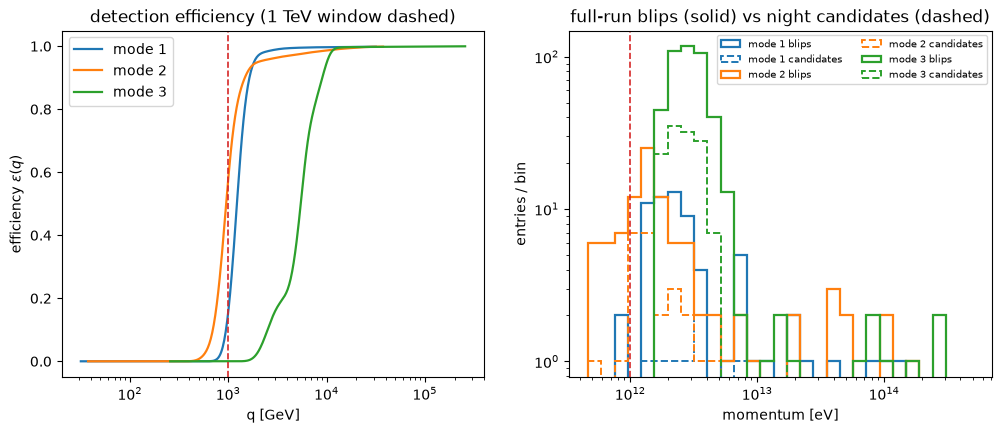

mode 1:   66 full-run blips (  64 above the window),    8 night candidates (   8 inside it)
mode 2:   99 full-run blips (  79 above the window),   26 night candidates (  24 inside it)
mode 3:  443 full-run blips ( 443 above the window),  126 night candidates ( 126 inside it)
every candidate is one of the blips: True


In [14]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 4.5))

Q_TH = float(rel.attrs["q_thresh_gev"])     # GeV; the analysis window opens here
colour = {}
for mode in (1, 2, 3):
    q, eff = rel.efficiency_curve(mode)
    (ln,) = a0.plot(q, eff, lw=1.6, label=f"mode {mode}")
    colour[mode] = ln.get_color()
a0.axvline(Q_TH, color="#d62728", ls="--", lw=1.2)
a0.set_xscale("log")
a0.set_xlabel("q [GeV]")
a0.set_ylabel(r"efficiency $\varepsilon(q)$")
a0.set_title("detection efficiency (1 TeV window dashed)")
a0.legend()

# blips are stored in eV, candidate momenta in GeV -- one shared eV axis
allb = np.concatenate([rel.all_blips(m) for m in (1, 2, 3)])
bins = np.logspace(np.log10(allb.min()), np.log10(allb.max()), 30)
for mode in (1, 2, 3):
    a1.hist(rel.all_blips(mode), bins=bins, histtype="step", lw=1.6,
            color=colour[mode], label=f"mode {mode} blips")
    a1.hist(rel.events(mode) * 1e9, bins=bins, histtype="step", lw=1.4,
            ls="--", color=colour[mode], label=f"mode {mode} candidates")
a1.axvline(Q_TH * 1e9, color="#d62728", ls="--", lw=1.2)
a1.set_xscale("log")
a1.set_yscale("log")
a1.set_xlabel("momentum [eV]")
a1.set_ylabel("entries / bin")
a1.set_title("full-run blips (solid) vs night candidates (dashed)")
a1.legend(fontsize=7, ncol=2)
plt.show()

for mode in (1, 2, 3):
    ev, bl = rel.events(mode), rel.all_blips(mode)
    print(f"mode {mode}: {bl.size:4d} full-run blips "
          f"({int((bl >= Q_TH * 1e9).sum()):4d} above the window), "
          f"{ev.size:4d} night candidates "
          f"({int((ev >= Q_TH).sum()):4d} inside it)")

# the two lists are nested, not thresholded: match each candidate to a blip
subset = all(
    np.isclose(rel.events(m)[:, None] * 1e9, rel.all_blips(m)[None, :],
               rtol=1e-9).any(axis=1).all()
    for m in (1, 2, 3))
print(f"every candidate is one of the blips: {subset}")

**Build pipeline.** `scripts/build_release.py` runs one per-`lambda` shard at
a time on a many-core node (all randomness pinned to a single `seed`), and
`scripts/assemble_release.py` merges the shards into a cube, computes the
reference curves, and writes the matching `release/provenance_*.json`. Both
released files come from **one** scan — the same shards, the same seed, the
same inputs — with the assembly step run twice, once per `--select`
hypothesis, which is why they share every axis and every detector dataset.
Nothing was subset or post-processed afterwards.

**Verify the download.** From `release/`: `sha256sum -c SHA256SUMS`, which
covers both cubes and everything shipped with them. Every root attribute below
is read straight from the file that is actually open, not typed in here, so it
always matches whatever cube this notebook ran against.

In [15]:
for k in ("version_tag", "created", "git_commit", "git_dirty", "seed",
         "t_exposure_s", "q_thresh_gev", "b_constrained_max_m", "df"):
    print(f"{k:26s} {rel.attrs.get(k)}")
# when the build tree was dirty the file records exactly which paths were
dirty = json.loads(rel.attrs.get("git_dirty_files_json") or "[]")
print(f"{'git_dirty_files':26s} {len(dirty)} "
      f"(full list in attrs['git_dirty_files_json'])")
# the flux cut and the assumption behind it, named per file
for k in sorted(k for k in rel.attrs if k.startswith("m_cut_")
                and not k.endswith("_derivation")):
    print(f"{k:26s} {rel.attrs.get(k)}")
print("packages", rel.attrs.get("packages_json"))

version_tag                v8.0-night-m0p356mg-q1TeV-nocap-wmarg
created                    2026-08-12T16:20:24.121864+00:00
git_commit                 fd46b03eb5ae6fc845bbc5ae6748a9afd81c4e78
git_dirty                  True
seed                       20260702
t_exposure_s               790778.0
q_thresh_gev               1000.0
b_constrained_max_m        nan
df                         3
git_dirty_files            14 (full list in attrs['git_dirty_files_json'])
m_cut_10cm_f1_gev          611068455417254.0
m_cut_applied_to_stored_surfaces False
m_cut_b_cap_m              0.1
m_cut_n_transits_required  3.0
packages {"numpy": "2.5.1", "scipy": "1.18.0", "h5py": "3.16.0", "optimum_interval": "0.3.0", "luhdm": "0.1.0", "matplotlib": "3.11.1", "pandas": "3.0.3", "python": "3.14.6"}


**Citation.** *POLONAISE UHDM data release* — DOI `<Zenodo placeholder>`. Cite
the release DOI alongside the analysis paper `<paper placeholder>`.

**What the numbers mean.** `extremeness >= C` at a point is the statement
that this `(f_DM, atmosphere, m_DM, alpha_n, lambda)` combination is
**excluded at confidence `C`** by the observed candidates, with no background
model assumed. Unmodelled backgrounds can only *weaken* an exclusion — never
fake one — so the excluded regions are conservative.

In [16]:
rel.close()
relB.close()
srel.close()
# A plain open + close is fine in a notebook. Scripts should prefer the
# context manager (either loader supports `with ... as rel:`), which closes
# the file even if an exception is raised mid-analysis.
print("release files closed")

release files closed
